# 1. 데이터 수집 및 확인

In [11]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display
from common.utils import train_test_split_by_target
from common.modeling import Modeling
from common.preprocessing import TitanicPreprocessor

train = pd.read_csv('csv/train.csv')
test = pd.read_csv('csv/test.csv')
submission = pd.read_csv('csv/submission.csv')

In [12]:
print("train shape:", train.shape)
display(train.head())

print("test shape:", test.shape)
display(test.head())

train shape: (916, 12)


,passengerid,survived,pclass,name,gender,age,sibsp,parch,ticket,fare,cabin,embarked
0,0,0,2,"Wheeler, Mr. Edwin Frederick""""",male,NaN,0,0,SC/PARIS 2159,12.8750,NaN,S
1,1,0,3,"Henry, Miss. Delia",female,NaN,0,0,382649,7.7500,NaN,Q
2,2,1,1,"Hays, Mrs. Charles Melville (Clara Jennings Gr...",female,52.0,1,1,12749,93.5000,B69,S
3,3,1,3,"Andersson, Mr. August Edvard (""Wennerstrom"")",male,27.0,0,0,350043,7.7958,NaN,S
4,4,0,2,"Hold, Mr. Stephen",male,44.0,1,0,26707,26.0000,NaN,S


test shape: (393, 11)


,passengerid,pclass,name,gender,age,sibsp,parch,ticket,fare,cabin,embarked
0,916,3,"McGowan, Miss. Anna ""Annie""",female,15.0,0,0,330923,8.0292,NaN,Q
1,917,2,"Pinsky, Mrs. (Rosa)",female,32.0,0,0,234604,13.0000,NaN,S
2,918,3,"McCarthy, Miss. Catherine Katie""""",female,NaN,0,0,383123,7.7500,NaN,Q
3,919,3,"Franklin, Mr. Charles (Charles Fardon)",male,NaN,0,0,SOTON/O.Q. 3101314,7.2500,NaN,S
4,920,1,"Wick, Mrs. George Dennick (Mary Hitchcock)",female,45.0,1,1,36928,164.8667,NaN,S


# 2. 메타 정보 확인

In [13]:
# train 데이터 기본 정보
print(train.shape)
print(train.columns.tolist())
train.info()
print(train.dtypes)


(916, 12)
['passengerid', 'survived', 'pclass', 'name', 'gender', 'age', 'sibsp', 'parch', 'ticket', 'fare', 'cabin', 'embarked']
<class 'pandas.DataFrame'>
RangeIndex: 916 entries, 0 to 915
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   passengerid  916 non-null    int64  
 1   survived     916 non-null    int64  
 2   pclass       916 non-null    int64  
 3   name         916 non-null    str    
 4   gender       916 non-null    str    
 5   age          736 non-null    float64
 6   sibsp        916 non-null    int64  
 7   parch        916 non-null    int64  
 8   ticket       916 non-null    str    
 9   fare         916 non-null    float64
 10  cabin        198 non-null    str    
 11  embarked     915 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 86.0 KB
passengerid      int64
survived         int64
pclass           int64
name               str
gender             str
age           

In [14]:
print("결측치 개수")
print(train.isna().sum())
print("결측치 비율")
print(train.isna().mean())
print("고유값 개수")
print(train.nunique())
display(train.describe(include="all"))

결측치 개수
passengerid      0
survived         0
pclass           0
name             0
gender           0
age            180
sibsp            0
parch            0
ticket           0
fare             0
cabin          718
embarked         1
dtype: int64
결측치 비율
passengerid    0.000000
survived       0.000000
pclass         0.000000
name           0.000000
gender         0.000000
age            0.196507
sibsp          0.000000
parch          0.000000
ticket         0.000000
fare           0.000000
cabin          0.783843
embarked       0.001092
dtype: float64
고유값 개수
passengerid    916
survived         2
pclass           3
name           915
gender           2
age             92
sibsp            7
parch            8
ticket         703
fare           251
cabin          146
embarked         3
dtype: int64


,passengerid,survived,pclass,name,gender,age,sibsp,parch,ticket,fare,cabin,embarked
count,916.000000,916.000000,916.000000,916,916,736.000000,916.000000,916.000000,916,916.000000,198,915
unique,NaN,NaN,NaN,915,2,NaN,NaN,NaN,703,NaN,146,3
top,NaN,NaN,NaN,"Connolly, Miss. Kate",male,NaN,NaN,NaN,CA. 2343,NaN,B57 B59 B63 B66,S
freq,NaN,NaN,NaN,2,589,NaN,NaN,NaN,7,NaN,4,645
mean,457.500000,0.377729,2.292576,NaN,NaN,29.698370,0.507642,0.361354,NaN,32.402710,NaN,NaN
std,264.570721,0.485084,0.838675,NaN,NaN,14.185627,1.044866,0.828054,NaN,50.506411,NaN,NaN
min,0.000000,0.000000,1.000000,NaN,NaN,0.170000,0.000000,0.000000,NaN,0.000000,NaN,NaN
25%,228.750000,0.000000,2.000000,NaN,NaN,21.000000,0.000000,0.000000,NaN,7.895800,NaN,NaN
50%,457.500000,0.000000,3.000000,NaN,NaN,28.000000,0.000000,0.000000,NaN,14.458300,NaN,NaN
75%,686.250000,1.000000,3.000000,NaN,NaN,38.000000,1.000000,0.000000,NaN,30.017700,NaN,NaN


In [10]:
# test 데이터 기본 정보
print(test.shape)
print(test.columns.tolist())
test.info()
print(test.dtypes)
print("결측치 개수")
print(test.isna().sum())
print("결측치 비율")
print(test.isna().mean())
print("고유값 개수")
print(test.nunique())
display(test.describe(include="all"))

(393, 11)
['passengerid', 'pclass', 'name', 'gender', 'age', 'sibsp', 'parch', 'ticket', 'fare', 'cabin', 'embarked']
<class 'pandas.DataFrame'>
RangeIndex: 393 entries, 0 to 392
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   passengerid  393 non-null    int64  
 1   pclass       393 non-null    int64  
 2   name         393 non-null    str    
 3   gender       393 non-null    str    
 4   age          310 non-null    float64
 5   sibsp        393 non-null    int64  
 6   parch        393 non-null    int64  
 7   ticket       393 non-null    str    
 8   fare         392 non-null    float64
 9   cabin        97 non-null     str    
 10  embarked     392 non-null    str    
dtypes: float64(2), int64(4), str(5)
memory usage: 33.9 KB
passengerid      int64
pclass           int64
name               str
gender             str
age            float64
sibsp            int64
parch            int64
ticket             str

,passengerid,pclass,name,gender,age,sibsp,parch,ticket,fare,cabin,embarked
count,393.000000,393.000000,393,393,310.000000,393.000000,393.000000,393,392.000000,97,392
unique,NaN,NaN,393,2,NaN,NaN,NaN,345,NaN,86,3
top,NaN,NaN,"McGowan, Miss. Anna ""Annie""",male,NaN,NaN,NaN,220845,NaN,F4,S
freq,NaN,NaN,1,254,NaN,NaN,NaN,4,NaN,4,269
mean,1112.000000,2.300254,NaN,NaN,30.315065,0.478372,0.440204,NaN,35.381643,NaN,NaN
std,113.593574,0.836919,NaN,NaN,14.955056,1.035180,0.946051,NaN,54.582654,NaN,NaN
min,916.000000,1.000000,NaN,NaN,0.420000,0.000000,0.000000,NaN,0.000000,NaN,NaN
25%,1014.000000,2.000000,NaN,NaN,21.000000,0.000000,0.000000,NaN,7.895800,NaN,NaN
50%,1112.000000,3.000000,NaN,NaN,28.000000,0.000000,0.000000,NaN,14.281250,NaN,NaN
75%,1210.000000,3.000000,NaN,NaN,40.000000,1.000000,1.000000,NaN,35.125000,NaN,NaN


In [5]:
print("train 컬럼")
print(train.columns.tolist())
print("test 컬럼")
print(test.columns.tolist())
train_only = set(train.columns) - set(test.columns)
test_only = set(test.columns) - set(train.columns)
print("train에만 있는 컬럼:", train_only)
print("test에만 있는 컬럼:", test_only)

train 컬럼
['passengerid', 'survived', 'pclass', 'name', 'gender', 'age', 'sibsp', 'parch', 'ticket', 'fare', 'cabin', 'embarked']
test 컬럼
['passengerid', 'pclass', 'name', 'gender', 'age', 'sibsp', 'parch', 'ticket', 'fare', 'cabin', 'embarked']
train에만 있는 컬럼: {'survived'}
test에만 있는 컬럼: set()


# 3. Target 정의
train에만 있는 실제 컬럼과 제출 템플릿을 교차 확인 !
passengerid : 행 식별자이므로 피처에서 제외
test.csv : target 없는 거 정상

In [15]:
assert len(train_only) == 1 and not test_only # 컬럼 차이 검증

assert train_only == {"survived"}
target_col = "survived"
assert target_col in submission.columns
id_col = "passengerid"
assert id_col in submission.columns and id_col in test.columns
assert train[id_col].is_unique and test[id_col].is_unique
assert train[id_col].notna().all() and test[id_col].notna().all()
assert set(train[id_col]).isdisjoint(test[id_col])

X = train.drop(columns=[target_col, id_col])
y = train[target_col]
X_test_raw = test.drop(columns=id_col)
assert X.columns.equals(X_test_raw.columns)
assert y.notna().all()
print('target:', target_col, 'ID:', id_col, 'X/y:', X.shape, y.shape)

target: survived ID: passengerid X/y: (916, 10) (916,)


# 4. Target 데이터 분석
survived : 저장 dtype은 정수형, 의미는 생존 여부를 나타내는 범주형 target

그래서 이진 분류 - stratify 사용


EDA와 전처리보다 먼저 학습/validation을 분리 !!

공통 split 함수는 seed 42, stratify, 기본 validation 25%를 사용

In [17]:
# 각 class간의 비율 확인 
train['survived'].value_counts() / train.shape[0]

survived
0    0.622271
1    0.377729
Name: count, dtype: float64

# 5. 핵심 EDA 확인

In [19]:
# target column은 Survived이다.
## 이렇게 잘 쓰이는 column은 변수로 정의하면 여러 모로 쓰기 편하다.
### target 변수가 불균형한 것을 확인 가능하다.(이 수치는, 그냥 다 죽었다로 평가해도 61.6%의 정확도를 나온다는 이야기다)
#### 따라서, 이러한 불균형을 해결하기 위하여, 추후 SMOTE를 통하여 oversampling 하는 방향 역시 고려가 필요하다.
##### overfitting 가능성이 있음에도, oversampling하는 가장 근본 이유는 데이터 양이 매우 적기 떄문이다.

target = 'survived'
print(train[target].value_counts())
print(train[target].value_counts()/ len(train[target]))

survived
0    570
1    346
Name: count, dtype: int64
survived
0    0.622271
1    0.377729
Name: count, dtype: float64


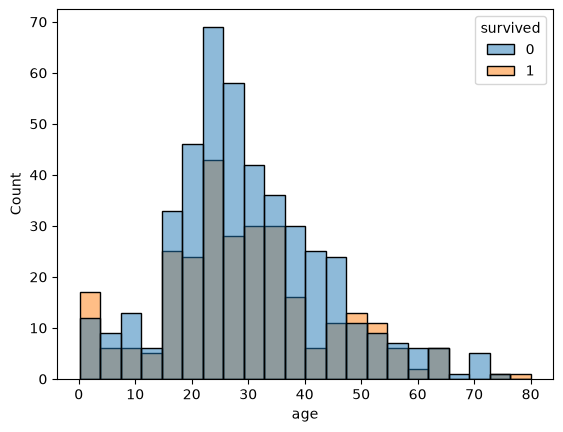

In [20]:
# 나이대에 따라, 확인 할 수 있는 사실은, 영유아/노인들의 상대적인 생존 비율이 높다라는 사실이다.
### 나이대는 편의상 중앙값으로 결측치 처리가 필요하다.
sns.histplot(x=train['age'], hue=train[target])
plt.show()

<Axes: >

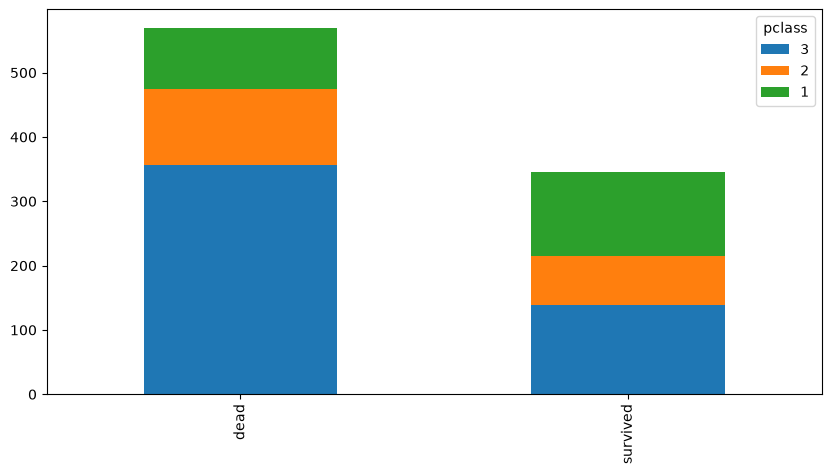

In [22]:
cat_cols = ['dead', 'survived']
temp = []
for idx, cat in enumerate(cat_cols):
    globals()['temp_{}'.format(cat)] = train[train[target]==idx]['pclass'].value_counts()
    temp.append(globals()['temp_{}'.format(cat)])
df = pd.DataFrame(temp)
df.index = cat_cols
df.plot(kind='bar', stacked=True, figsize=(10,5))

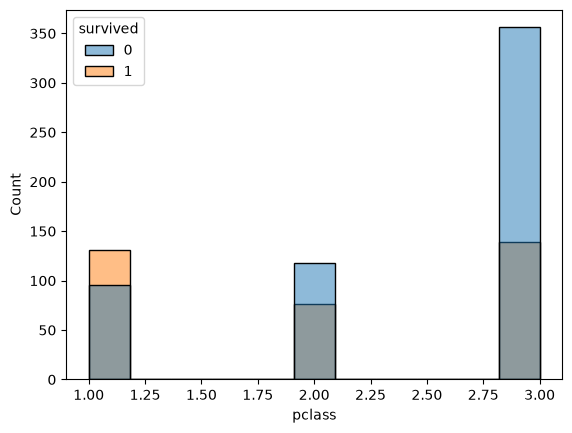

In [23]:
# 대략적으로 살펴봐도, 티켓의 등급(소득 수준)은 승객 생존에 매우 유의미한 영향을 끼쳤다는 사실을 알 수 있다.
sns.histplot(x=train['pclass'], hue=train[target])
plt.show()

<Axes: >

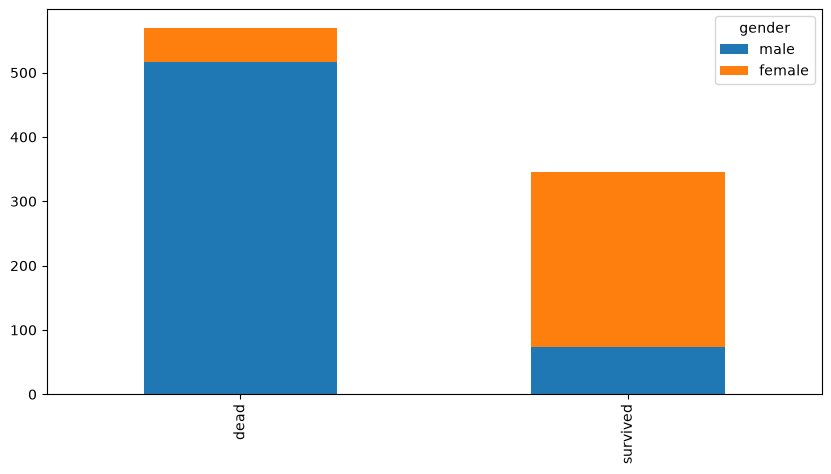

In [24]:
cat_cols = ['dead', 'survived']
temp = []
for idx, cat in enumerate(cat_cols):
    globals()['temp_{}'.format(cat)] = train[train[target]==idx]['gender'].value_counts()
    temp.append(globals()['temp_{}'.format(cat)])
df = pd.DataFrame(temp)
df.index = cat_cols
df.plot(kind='bar', stacked=True, figsize=(10,5))

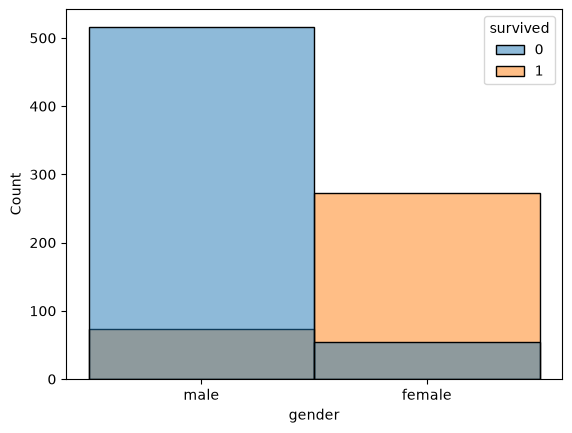

In [25]:
# 타이타닉에 대한 기본 배경 지식(여성이 더 생존했다)은 사실이었다.
sns.histplot(x=train['gender'], hue=train[target])
plt.show()

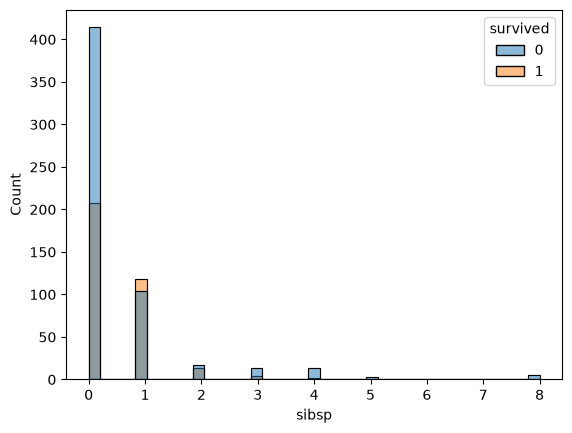

In [26]:
# 형제/배우자 2명 이상 탑승 여부는 표본이 매우 적어서 알 수 없지만,
## 한가지 알 수 있는 사실은 배우자가 있었다면, 남편이 아내를 살리기 위하여 노력했다라는 가설을 세울 수 있다.
### 추가적인 확인은 필요하겠지만, SibSp 1 중, 남성/여성 생존 비율을 확인해보는 것도 유의미해 보인다.
#### 실제 분석에 있어서는, 1을 제외한 값은 생존에 낮은 영향을 미치는 변수라고 볼 수 있다.
##### 따라서, 모델 성능 개선을 위하여, SibSp가 1이 아닌 값은 모두 0으로 가정하고 보는 분석 방법도 고려해볼만 하다.
sns.histplot(x=train['sibsp'], hue=train[target])
plt.show()

<Axes: >

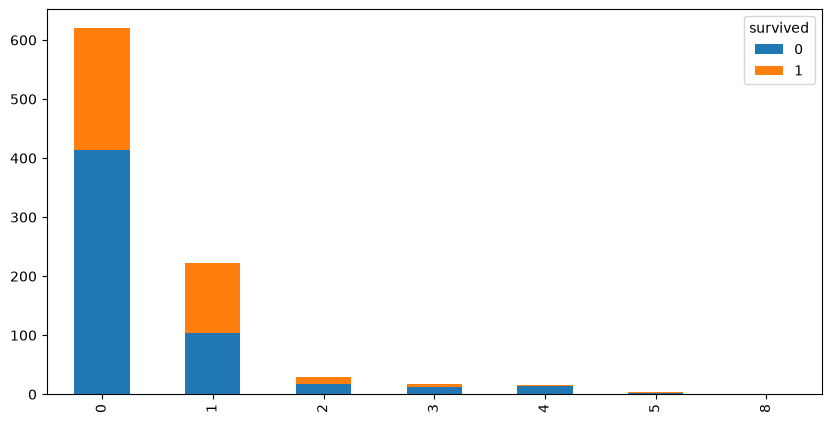

In [27]:
cat_cols = [0, 1, 2, 3, 4, 5, 8]
temp = []
for idx, cat in enumerate(cat_cols):
    globals()['temp_{}'.format(cat)] = train[train['sibsp']==idx][target].value_counts()
    temp.append(globals()['temp_{}'.format(cat)])
df = pd.DataFrame(temp)
df.index = cat_cols
df.plot(kind='bar', stacked=True, figsize=(10,5))

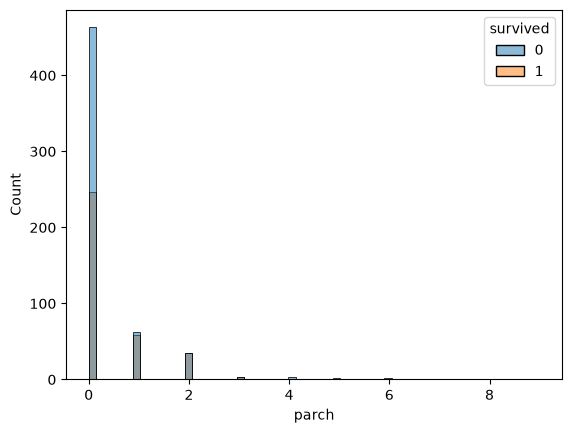

In [28]:
# 전체적인 부모/자녀 탑승 비율을 보면 알겠지만, 형제/배우자와 가족과 탑승한 비율이 매우 적다.
# 이는 당시에는 혼자서 초호화유람선을 타고 즐기는 것이 트렌드였거나,
# 노동자 계층이 일을 위하여 탑승을 많이 했다라고 볼 수 있다.(당연히 후자로 예상된다.)
# 이곳에서도, 유의미한 상황은 가족과 같이 탑승한 경우(Parch >= 1) 생존에 유의미한 영향을 끼쳤음을 알 수 있다.

sns.histplot(x=train['parch'], hue=train[target])
plt.show()

<Axes: >

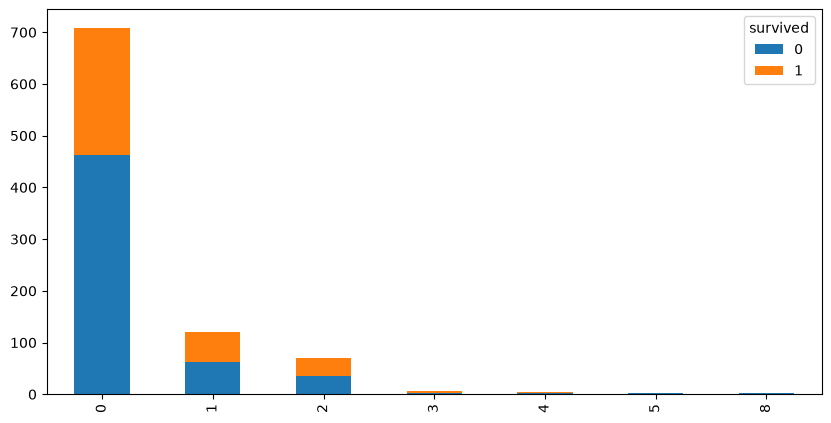

In [29]:
cat_cols = [0, 1, 2, 3, 4, 5, 8]
temp = []
for idx, cat in enumerate(cat_cols):
    globals()['temp_{}'.format(cat)] = train[train['parch']==idx][target].value_counts()
    temp.append(globals()['temp_{}'.format(cat)])
df = pd.DataFrame(temp)
df.index = cat_cols
df.plot(kind='bar', stacked=True, figsize=(10,5))

In [30]:
# 티켓 번호는 말그대로 티켓의 번호로 보인다.(규칙성이 있을 수도 있겠으나, 공수가 많이 들어 이에 대한 분석은 생략)
train['ticket'].value_counts()

ticket
CA. 2343        7
3101295         7
1601            7
CA 2144         6
S.O.C. 14879    6
               ..
2621            1
315091          1
28665           1
35852           1
PC 17606        1
Name: count, Length: 703, dtype: int64

In [31]:
train['cabin'].value_counts()

cabin
B57 B59 B63 B66    4
G6                 4
F2                 4
B96 B98            3
F33                3
                  ..
D11                1
C46                1
D22                1
C132               1
D38                1
Name: count, Length: 146, dtype: int64

In [34]:
train['cabin'].isnull().sum()

np.int64(718)

In [35]:
# 우선 Cabin의 가변수 X를 넣어, PClass에 따라서, 과연 유의미한 소실이 있는지 확인해볼 필요가 있다.
## 그 당시, 잘 사는 사람의 정보가 소실되었을 가능성은 낮다. 
### 추가적으로, Cabin의 앞글자만 떼어 내어 Deck이라는 변수를 생성한다.
train['cabin'] = train['cabin'].fillna('X')
train['deck'] = train['cabin'].str[0]

In [36]:
train['pclass'].value_counts()


pclass
3    495
1    227
2    194
Name: count, dtype: int64

In [37]:
k = train.sort_values(by='deck')


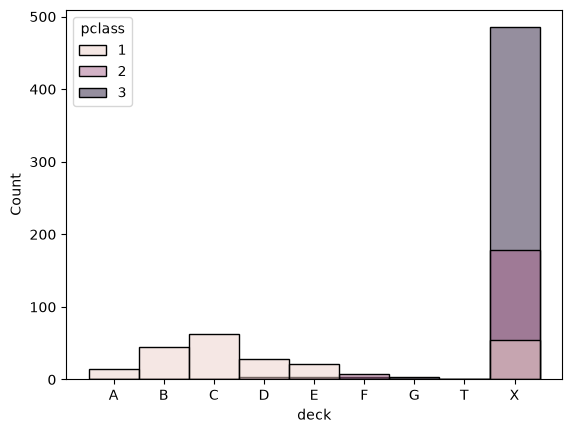

In [38]:
## A~E까지는 Pclass 1이라는 계산이 나온다.
sns.histplot(x=k['deck'], hue=k['pclass'])
plt.show()


<Axes: >

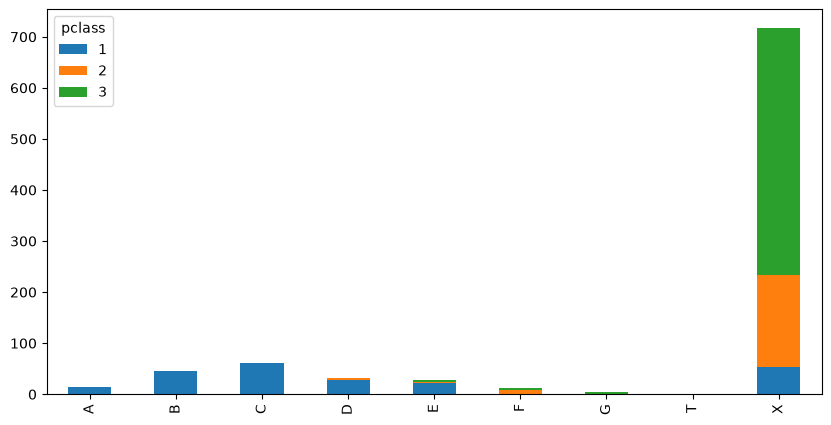

In [40]:
cat_cols = k['deck'].unique().tolist()
temp = []
for idx, cat in enumerate(cat_cols):
    globals()['temp_{}'.format(cat)] = train[train['deck']==cat]['pclass'].value_counts()
    temp.append(globals()['temp_{}'.format(cat)])
df = pd.DataFrame(temp)
df.index = cat_cols
df.plot(kind='bar', stacked=True, figsize=(10,5))

In [41]:
# A와 T가 있지만, 평균적인 운임을 고려한다면, 과연 해당 자리는 비싼 자리인가에 대한 의구심이 잡힌다.(해당 자리는 E와 동일하다고 볼 필요 존재)
## Fare에 맞춰서 완벽하게 나누기는 어려운 상황이다.
### 따라서, 각 Pclass에 따라서, 소수점을 사용하는 feature scaling을 진행하고,
#### 결측치는 각 Pclass의 Median으로 대체한다.
##### {'A':1.5, 'T':1.5, 'B': 0, 'C':0.5, 'D':1, 'E':1.5, 'F':2.0, 'G':2.5}
train.groupby(['pclass', 'deck']).agg({'survived':['count','sum','mean'],
                                           'fare': ['count','sum','mean', 'min', 'max','median']})

survived                 fare                                  \
               count  sum      mean count        sum        mean      min   
pclass deck                                                                 
1      A          15    7  0.466667    15   638.0208   42.534720  26.0000   
       B          45   32  0.711111    45  5452.3667  121.163704   0.0000   
       C          62   33  0.532258    62  6079.0126   98.048590  25.7000   
       D          28   20  0.714286    28  1686.0793   60.217118  25.9292   
       E          22   15  0.681818    22  1505.3917   68.426895  25.5875   
       T           1    0  0.000000     1    35.5000   35.500000  35.5000   
       X          54   24  0.444444    54  3613.8831   66.923761   0.0000   
2      D           4    1  0.250000     4    54.7833   13.695825  12.8750   
       E           3    2  0.666667     3    34.0000   11.333333  10.5000   
       F           8    5  0.625000     8   138.0000   17.250000  10.5000   
       X         179   68  0.379888   179  3728.4957   20.829585   0.0000   
3      E           2    2  1.000000     2    20.5250   10.262500   8.0500   
       F           4    1  0.250000     4    44.4667   11.116675   7.2292   
       G           4    2  0.500000     4    54.3250   13.581250  10.4625   
       X         485  134  0.276289   485  6596.0329   13.600068   0.0000   

                                 
                  max    median  
pclass deck                      
1      A      81.8583  34.65420  
       B     512.3292  82.26670  
       C     263.0000  83.31665  
       D     113.2750  57.95625  
       E     134.5000  55.44170  
       T      35.5000  35.50000  
       X     512.3292  37.04165  
2      D      15.0458  13.43125  
       E      13.0000  10.50000  
       F      26.0000  13.00000  
       X      73.5000  15.05000  
3      E      12.4750  10.26250  
       F      22.3583   7.43960  
       G      16.7000  13.58125  
       X      69.5500   8.05000

In [42]:
# 이름에 있어서는, 특수한 정보를 뽑을 수 있는가 고려도 필요하다.
## SibSp, Parch와 함께 하여, 가족별로 모으는 방식도 고려가 가능하지만, 편의상 생략하였다.
### 모든 이름은, 외국 이름답게 .이 들어가 있다는 것이 파악 가능하다.
#### 온점(.)을 기준으로, 특수 정보가 있는지 확인해보았다.

train['name'].head(30)

0                        Wheeler, Mr. Edwin Frederick""
1                                    Henry, Miss. Delia
2     Hays, Mrs. Charles Melville (Clara Jennings Gr...
3          Andersson, Mr. August Edvard ("Wennerstrom")
4                                     Hold, Mr. Stephen
5              Rosblom, Mrs. Viktor (Helena Wilhelmina)
6                                   Novel, Mr. Mansouer
7              Kelly, Miss. Anna Katherine "Annie Kate"
8                            de Brito, Mr. Jose Joaquim
9                                  Petersen, Mr. Marius
10                Dodge, Mrs. Washington (Ruth Vidaver)
11                      Pettersson, Miss. Ellen Natalia
12                                Sinkkonen, Miss. Anna
13                         Sage, Miss. Constance Gladys
14                                  Toomey, Miss. Ellen
15                                Jardin, Mr. Jose Neto
16                              Spinner, Mr. Henry John
17        Carter, Mrs. Ernest Courtenay (Lilian 

In [43]:
train['name'].str.extract('([A-Za-z]+)\.').value_counts()

<>:1: SyntaxWarning: "\." is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\."? A raw string is also an option.
<>:1: SyntaxWarning: "\." is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\."? A raw string is also an option.
C:\Users\Playdata\AppData\Local\Temp\ipykernel_7836\982460553.py:1: SyntaxWarning: "\." is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\."? A raw string is also an option.
  train['name'].str.extract('([A-Za-z]+)\.').value_counts()


0       
Mr          528
Miss        185
Mrs         138
Master       42
Rev           6
Dr            5
Col           3
Major         2
Don           1
Ms            1
Jonkheer      1
Mlle          1
Countess      1
Capt          1
Sir           1
Name: count, dtype: int64

In [44]:
train['title'] = train['name'].str.extract('([A-Za-z]+)\.')
pd.crosstab(train['title'], train['gender'])

<>:1: SyntaxWarning: "\." is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\."? A raw string is also an option.
<>:1: SyntaxWarning: "\." is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\."? A raw string is also an option.
C:\Users\Playdata\AppData\Local\Temp\ipykernel_7836\100647285.py:1: SyntaxWarning: "\." is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\."? A raw string is also an option.
  train['title'] = train['name'].str.extract('([A-Za-z]+)\.')


gender,female,male
title,,
Capt,0,1
Col,0,3
Countess,1,0
Don,0,1
Dr,1,4
Jonkheer,0,1
Major,0,2
Master,0,42
Miss,185,0


In [45]:
test['name'].str.extract('([A-Za-z]+)\.').value_counts()

<>:1: SyntaxWarning: "\." is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\."? A raw string is also an option.
<>:1: SyntaxWarning: "\." is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\."? A raw string is also an option.
C:\Users\Playdata\AppData\Local\Temp\ipykernel_7836\3982846054.py:1: SyntaxWarning: "\." is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\."? A raw string is also an option.
  test['name'].str.extract('([A-Za-z]+)\.').value_counts()


0     
Mr        229
Miss       75
Mrs        59
Master     19
Dr          3
Rev         2
Dona        1
Lady        1
Mme         1
Mlle        1
Col         1
Ms          1
Name: count, dtype: int64

In [46]:
# 타이틀 교체를 위한 변수 정의
title_list = [['Capt', 'Col', 'Countess', 'Don','Dona', 'Dr', 'Jonkheer','Lady','Major', 'Rev', 'Sir'],
             ['Mlle', 'Ms'], 'Mme']
title_replace_list = ['Other', 'Miss', 'Mrs']

In [47]:
# 마지막으로 Embarked를 살펴보자.
## 타이타닉의 시대상을 고려할 때, 승선지는 높은 확률로 소득 수준과 관련이 있을 수 있다.
### 사실 이 수치만 봐도 사우스햄튼(S)로 결측치를 처리해도 무방해보인다.
#### 전체적으로, S는 3등급 고객이었을 가능성이 높다.

train['embarked'].value_counts()

embarked
S    645
C    189
Q     81
Name: count, dtype: int64

In [ ]:
## 비어있는 값은 S로 바꾼다.
### 사실상 C는 잘 사는 동네였을 가능성이 높다.
cat_cols = train['embarked'].unique().tolist()
temp = []
for idx, cat in enumerate(cat_cols):
    globals()['temp_{}'.format(cat)] = train[train['embarked']==cat]['pclass'].value_counts()
    temp.append(globals()['temp_{}'.format(cat)])
df = pd.DataFrame(temp)
df.index = cat_cols
df.plot(kind='bar', stacked=True, figsize=(10,5))

# 6. 데이터 전처리
## 6-1. 결측치
cabin :  20%를 크게 넘어 원본 객실번호를 제외하자
age : 생존과 연관될 수 있는 기본 변수이므로 유지하고 성별·등급별 중앙값으로 치환
그룹 통계가 없으면 학습 전체 중앙값을 씀
나머지 수치형은 중앙값, 범주형은 최빈값
validation/test에는 transform만 꼭 해야 해
최종 재학습 때는 전체 train에서 새 전처리 객체를 fit ! 

학습 부분 cabin 결측은 543/687행(79.0%)입니다. 
알려진 개별 객실번호도 표본이 작은 그룹이 많아 원본 번호는 첫 baseline에서 제외  . . 객실 정보가 무의미하다고 단정하는 것은 아님

In [48]:
train = pd.read_csv('csv/train.csv')
test = pd.read_csv('csv/test.csv')

In [51]:
# x, y_train 데이터 분리
target = "survived"
x = train.drop(target, axis=1)
y_train = train[target]
x = pd.concat([x, test])

In [49]:
# row 중복 제거 
print(f"before: {train.shape}")

# 평가는 학습을 하는 데이터가 아니기 때문에 row 중복 제거 제외
train.drop_duplicates(inplace=True)
print(f"after: {train.shape}")

before: (916, 12)
after: (916, 12)


In [52]:
# x 정렬하지 말고, y_train 갯수만큼만 train data로 나눌 
x.shape, y_train.shape

((1309, 11), (916,))

In [53]:
# x 데이터 확인
x = x.reset_index(drop=True)
x.tail()

,passengerid,pclass,name,gender,age,sibsp,parch,ticket,fare,cabin,embarked
1304,1304,3,"Healy, Miss. Hanora ""Nora""",female,NaN,0,0,370375,7.7500,NaN,Q
1305,1305,1,"Hippach, Miss. Jean Gertrude",female,16.0,0,1,111361,57.9792,B18,C
1306,1306,3,"Ayoub, Miss. Banoura",female,13.0,0,0,2687,7.2292,NaN,C
1307,1307,3,"Andersson, Mrs. Anders Johan (Alfrida Konstant...",female,39.0,1,5,347082,31.2750,NaN,S
1308,1308,3,"Nilsson, Miss. Helmina Josefina",female,26.0,0,0,347470,7.8542,NaN,S


In [54]:
x.info()

<class 'pandas.DataFrame'>
RangeIndex: 1309 entries, 0 to 1308
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   passengerid  1309 non-null   int64  
 1   pclass       1309 non-null   int64  
 2   name         1309 non-null   str    
 3   gender       1309 non-null   str    
 4   age          1046 non-null   float64
 5   sibsp        1309 non-null   int64  
 6   parch        1309 non-null   int64  
 7   ticket       1309 non-null   str    
 8   fare         1308 non-null   float64
 9   cabin        295 non-null    str    
 10  embarked     1307 non-null   str    
dtypes: float64(2), int64(4), str(5)
memory usage: 112.6 KB


In [55]:
x.describe().T

,count,mean,std,min,25%,50%,75%,max
passengerid,1309.0,654.000000,378.020061,0.00,327.0000,654.0000,981.000,1308.0000
pclass,1309.0,2.294882,0.837836,1.00,2.0000,3.0000,3.000,3.0000
age,1046.0,29.881138,14.413493,0.17,21.0000,28.0000,39.000,80.0000
sibsp,1309.0,0.498854,1.041658,0.00,0.0000,0.0000,1.000,8.0000
parch,1309.0,0.385027,0.865560,0.00,0.0000,0.0000,0.000,9.0000
fare,1308.0,33.295479,51.758668,0.00,7.8958,14.4542,31.275,512.3292


In [57]:
# Pclass 1, 2, 3에 따라 결측치는 각각 C, F, F로 변경
pd.crosstab(x['pclass'], x['cabin'].str[0])

cabin,A,B,C,D,E,F,G,T
pclass,,,,,,,,
1,22,65,94,40,34,0,0,1
2,0,0,0,6,4,13,0,0
3,0,0,0,0,3,8,5,0


In [63]:
### 결측치 정리 및 변수 삭제

# PassengerId 정리
## PassengerId drop
# x = x.drop('passengerid', axis = 1)

# Age 정리
## 결측치는 중앙값으로 처리
### AgeBand 생성 0~6: 유아, 7~17: 청소년, 18~37: 청년, 38~57: 장년, 58up: 노년로 대체
#### Age drop
x['age'] = x['age'].fillna(x['age'].median())
age_div_list = [6, 17, 37, 57, 10000]
x['age_band'] = 0
for i in range(5):
    x.loc[x['age'] <= age_div_list[i],'age_band'] = i
    x.loc[x['age'] <= age_div_list[i],'age'] = 100000
x = x.drop('age', axis = 1)

# Name 정리
## Name drop
### 타이틀 교체를 위한 변수 정의
##### 타이틀 교체(Cabin하고 같이)
###### 타이틀 가변수화(가변수화하면 가변수할 변수도 함께 제거된다.)
x['title'] = x['name'].str.extract('([A-Za-z]+)\.')
x = x.drop('name', axis = 1)
title_list = [['Capt', 'Col', 'Countess', 'Don','Dona', 'Dr', 'Jonkheer','Lady','Major', 'Rev', 'Sir'],
             ['Mlle', 'Ms'], 'Mme']
title_repl_list = ['Other', 'Miss', 'Mrs']
for i in range(3):
    x['title'] = x['title'].replace(title_list[i], title_repl_list[i])
x = pd.get_dummies(x,columns=['title'])

# gender 정리
## gender 가변수화
x = pd.get_dummies(x,columns=['gender'])

# Ticket 정리
## Ticket drop
x = x.drop('ticket', axis = 1)

# Fare 정리
## Fare는 최빈값으로 대체(1개 밖에 없음, test_data)
x['fare'] = x['fare'].fillna(x['fare'].median())

# Cabin 정리
## Cabin 결측치 'X'로 우선 처리
### Cabin 첫 글자에서 Deck 정보 추출
#### Cabin 삭제
##### Pclass 1, 2, 3에 따라 결측치는 각각 C, F, F로 변경
###### {'A':1.5, 'T':1.5, 'B': 0, 'C':0.5, 'D':1, 'E':1.5, 'F':2.0, 'G':2.5} 값 변경
x['cabin'] = x['cabin'].fillna('X')
x['deck'] = x['cabin'].str[0]
x = x.drop('cabin', axis = 1)

deck_div_list = ['C','F','F']
for i, div in enumerate(deck_div_list):
    x.loc[(x['pclass'] == i+1)&
          (x['deck']== 'X'),'deck'] = div

x['Deck_dummies'] = 0

deck_list = ['A', 'T', 'B', 'C', 'D', 'E', 'F', 'G']
deck_repl_list = [1.5, 1.5, 0, 0.5, 1, 1.5, 2.0, 2.5]

for d, r in zip(deck_list, deck_repl_list):
    x.loc[x['deck'] == d, 'Deck_dummies'] = r
x = x.drop('deck', axis = 1)

# Emabarked 정리
## 결측치 C로 변환
### 더미화
x['embarked'] = x['embarked'] = 'C'
x = pd.get_dummies(x,columns=['embarked'])

<>:24: SyntaxWarning: "\." is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\."? A raw string is also an option.
<>:24: SyntaxWarning: "\." is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\."? A raw string is also an option.
C:\Users\Playdata\AppData\Local\Temp\ipykernel_7836\2350299215.py:24: SyntaxWarning: "\." is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\."? A raw string is also an option.
  x['title'] = x['name'].str.extract('([A-Za-z]+)\.')


KeyError: 'age'

## 6-2. Feature 생성
기존 코드에서 `FamilySize = sibsp + parch + 1`과 `IsAlone`만 재사용 ㄱㄱ

In [ ]:
X_tr_features = prep.make_features(X_tr_clean)
X_valid_features = prep.make_features(X_valid_clean)
print(X_tr_features[['sibsp', 'parch', 'FamilySize', 'IsAlone']].head().to_string())

     sibsp  parch  FamilySize  IsAlone
595      0      1           2        0
148      0      0           1        1
347      1      1           3        0
731      0      2           3        0
457      0      0           1        1


## 6-3. 중복 제거
기존 코드의 `family_size`와 `FamilySize`는 같은 식이므로 `FamilySize`만 생성합니다.
이름/티켓 원문은 고유값이 많아 단순 baseline의 원핫 차원을 늘리므로 제외합니다.
완전 중복과 ID 제외 중복을 점검합니다. 전처리 후 같은 피처를 가진 서로 다른 승객은 중복 관측으로 단정하지 않고 유지합니다.
원본 완전 중복이 발견되면 분리 전에 처리해야 하므로 실행을 중단해 검토하게 합니다.

In [ ]:
raw_duplicates = train.duplicated().sum()
identity_free_duplicates = train.drop(columns=id_col).duplicated().sum()
print('원본 완전 중복:', raw_duplicates, 'ID 제외 중복:', identity_free_duplicates)
assert raw_duplicates == 0 and identity_free_duplicates == 0, '원본 중복을 검토한 뒤 split을 다시 수행하세요.'
X_tr_features = prep.select_features(X_tr_features)
X_valid_features = prep.select_features(X_valid_features)
print('피처가 같은 별도 승객 수(유지):', X_tr_features.duplicated().sum())
print('사용 피처:', X_tr_features.columns.tolist())

원본 완전 중복: 0 ID 제외 중복: 0
피처가 같은 별도 승객 수(유지): 80
사용 피처: ['pclass', 'gender', 'age', 'sibsp', 'parch', 'fare', 'embarked', 'FamilySize', 'IsAlone']


## 6-4. 데이터 인코딩
세 모델을 동일한 수치형 피처로 비교하도록 범주형 `gender`, `embarked`를 One-Hot Encoding합니다.
encoder.fit은 학습 부분에만 호출합니다. validation/test의 미관측 범주는 handle_unknown='ignore'로 처리합니다.

In [ ]:
prep.fit_encoding(X_tr_features)
X_tr_encoded = prep.transform_encoding(X_tr_features)
X_valid_encoded = prep.transform_encoding(X_valid_features)
print('범주형:', prep.cat_cols_, '인코딩 후:', X_tr_encoded.shape, X_valid_encoded.shape)
assert X_tr_encoded.columns.equals(X_valid_encoded.columns)

범주형: ['gender', 'embarked'] 인코딩 후: (687, 12) (229, 12)


## 6-5. 데이터 스케일링
기존 모듈의 XGBoost, LightGBM, CatBoost는 모두 트리 기반이므로 스케일링은 생략합니다.

In [ ]:
X_tr_model = X_tr_encoded
X_valid_model = X_valid_encoded
assert np.isfinite(X_tr_model.to_numpy()).all()
assert np.isfinite(X_valid_model.to_numpy()).all()
assert X_tr_model.index.equals(y_tr.index)

# 7. 모델 학습


In [ ]:
modeling = Modeling(X_tr_model.copy(), y_tr, cat_cols=[])
modeling.fit()
print('XGBoost / LightGBM / CatBoost 학습 완료')

XGBoost / LightGBM / CatBoost 학습 완료


# 8. Evaluation - AUC


In [ ]:
auc_result = modeling.evaluate(y_valid, X_valid_model.copy())
print(auc_result.to_string(index=False))
best = modeling.get_best_model()
print('선택:', best['model_name'], 'Validation AUC:', best['test_score'])

             model  train_auc  validation_auc
CatBoostClassifier   0.963079        0.900065
    LGBMClassifier   0.994433        0.894088
     XGBClassifier   0.996897        0.888396
선택: CatBoostClassifier Validation AUC: 0.900065051227842


# 9. 전체 train 데이터로 최종 학습
선택된 모델의 클래스와 파라미터로 새 객체를 생성하여 전체 train으로 재학습

In [ ]:
final_prep = TitanicPreprocessor()
X_full_model = final_prep.fit_transform(X)
final_model = type(best['model'])(**best['hpo'])
final_model.fit(X_full_model, y)
print('전체 train 최종 학습:', X_full_model.shape, final_model.__class__.__name__)

전체 train 최종 학습: (916, 12) CatBoostClassifier


# 10. test 예측
먼저 원본 submission 템플릿의 컬럼/ID/행 순서를 확인합니다.
사용자가 명시한 평가 기준 AUC와 템플릿의 실수형 0.5를 근거로 생존 확률을 제출합니다.
양성 클래스의 위치는 classes_에서 확인합니다. test 정답을 만들거나 성능 평가에 사용하지 않습니다.

In [ ]:
print('submission:', submission.shape, submission.columns.tolist())
print(submission.head().to_string(index=False))
assert submission.columns.tolist() == [id_col, target_col]
assert len(submission) == len(test)
assert submission[id_col].is_unique and submission[id_col].notna().all()
assert set(submission[id_col]) == set(test[id_col])
print('ID:', id_col, 'prediction:', target_col)
print('test와 ID 순서 일치:', submission[id_col].equals(test[id_col]))
assert pd.api.types.is_float_dtype(submission[target_col])
assert submission[target_col].between(0, 1).all()
X_test_model = final_prep.transform(X_test_raw)
assert X_full_model.columns.equals(X_test_model.columns)
positive_index = list(final_model.classes_).index(1)
predictions = final_model.predict_proba(X_test_model)[:, positive_index]
assert np.isfinite(predictions).all() and ((predictions >= 0) & (predictions <= 1)).all()

submission: (393, 2) ['passengerid', 'survived']
 passengerid  survived
         916       0.5
         917       0.5
         918       0.5
         919       0.5
         920       0.5
ID: passengerid prediction: survived
test와 ID 순서 일치: True


# 11. submission_result_1.csv 생성
원본 템플릿을 복사하여 예측 컬럼만 바꿉니다. ID로 매핑하므로 템플릿의 원래 행 순서를 유지합니다.
index=False로 저장한 실제 파일을 다시 읽어 검증합니다.

In [ ]:
result = submission.copy(deep=True)
by_id = pd.Series(predictions, index=test[id_col].to_numpy())
result[target_col] = result[id_col].map(by_id)
assert result[target_col].notna().all()
result.to_csv("submission_result_1.csv", index=False)
saved = pd.read_csv("submission_result_1.csv")
checks = {
    # 바로 위 read_csv가 성공하면 파일 존재도 확인됩니다.
    'test 행 수 일치': len(saved) == len(test),
    '원본 shape 유지': saved.shape == submission.shape,
    '컬럼명/순서 유지': saved.columns.equals(submission.columns),
    'ID 값/순서 유지': saved[id_col].equals(submission[id_col]),
    'NaN 없음': saved[target_col].notna().all(),
    '확률 실수형': pd.api.types.is_float_dtype(saved[target_col]),
    '확률 0~1 범위': saved[target_col].between(0, 1).all(),
}
assert all(checks.values()), checks
pd.testing.assert_frame_equal(saved.drop(columns=target_col), submission.drop(columns=target_col))
np.testing.assert_allclose(saved[target_col], by_id.loc[submission[id_col]], rtol=1e-12, atol=1e-15)
print('검증:', checks)
print('최종 shape:', saved.shape)
print(saved.head().to_string(index=False))
print('저장: submission_result_1.csv')

검증: {'test 행 수 일치': True, '원본 shape 유지': True, '컬럼명/순서 유지': True, 'ID 값/순서 유지': True, 'NaN 없음': np.True_, '확률 실수형': True, '확률 0~1 범위': np.True_}
최종 shape: (393, 2)
 passengerid  survived
         916  0.832588
         917  0.906221
         918  0.879633
         919  0.075956
         920  0.962691
저장: submission_result_1.csv
